In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import librosa
import random
import cv2
from matplotlib import cm

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from transformers import Resampler, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor, NoiseAdder

from config import TEST_SIZE, SEED, MAX_DURATION, MIN_DURATION, SAMPLING_RATE, N_MELS, N_FFT

from utils import plot_mel_spectrogram, save_mel_images

random.seed(SEED)

# Procesamiento de ciclos respiratorios

In [3]:
df = pd.read_csv('./data_preprocesada/ciclos/metadata.csv')

Buscamos identificar cualquier anormalidad en los ciclos, por ejemplo crepitaciones (_crackles_) y sibilancias (_wheezes_). Para esto combinamos las columnas correspondientes en una que será nuestro target.

In [4]:
df['label'] = np.where((df['crackles'] == 0) & (df['wheezes'] == 0), 0, 1)
df.head()

,patient,recording_index,location,mode,instrument,cycle_number,start_sec,end_sec,duration_sec,crackles,wheezes,cycle_wav_file,wav_base_file,age,sex,adult_bmi,child_weight,child_height,diagnosis,label
0,101,1b1,Al,sc,Meditron,1,0.036,0.579,0.543,0,0,101_1b1_Al_sc_Meditron_cycle1.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
1,101,1b1,Al,sc,Meditron,2,0.579,2.450,1.871,0,0,101_1b1_Al_sc_Meditron_cycle2.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
2,101,1b1,Al,sc,Meditron,3,2.450,3.893,1.443,0,0,101_1b1_Al_sc_Meditron_cycle3.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
3,101,1b1,Al,sc,Meditron,4,3.893,5.793,1.900,0,0,101_1b1_Al_sc_Meditron_cycle4.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
4,101,1b1,Al,sc,Meditron,5,5.793,7.521,1.728,0,0,101_1b1_Al_sc_Meditron_cycle5.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0


## Duración de los ciclos respiratorios

Hay ciclos respiratorios demasiado largos y demasiado cortos, nos quedamos con los que están entre 1 y 6 segundos (``config.py``).

Los ciclos demasiado cortos pueden producir imagenes o matrices muy dispersas.  
Los ciclos demasiado largos causan que tengamos que hacer un _padding_ excesivo y generan matrices demasiado grandes para ser procesadas por los modelos.

In [5]:
df = df[df['duration_sec'] < MAX_DURATION].copy()
df = df[df['duration_sec'] > MIN_DURATION].copy()

## Procesado

Definimos un nombre para el dataset y creamos una carpeta final

In [ ]:
dataset = 'aug'

os.makedirs(f'./data_procesada/ciclos/{dataset}', exist_ok=True)

El pipeline recibe una ruta, tenemos que construir un conjunto con todas las rutas y dividir en conjuntos de train y test.

In [7]:
X = df['cycle_wav_file'].tolist()
y = df['label'].tolist()

X = [os.path.join('./data_preprocesada/ciclos/', path) for path in X]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

### Augmentation
Traemos los paths de los audios de ruido real

Esta parte se ejecutá sólo si el nombre del dataset contiene 'aug'.

In [8]:
noise_paths = os.listdir('./dataset/ruido/train')
noise_paths = [os.path.join('./dataset/ruido/train', path) for path in noise_paths]

test_noise_paths = os.listdir('./dataset/ruido/test')
test_noise_paths = [os.path.join('./dataset/ruido/test', path) for path in test_noise_paths]

El primer paso del pipeline es el resampleo de los audios, se pasan a 16 kHz

In [9]:
resampler = Resampler()
X_train_resampled = resampler.fit_transform(X_train)
X_test_resampled = resampler.transform(X_test)

Para agregar el ruido instanciamos varios agragadores de ruido.
+ Ruido blanco
+ Ruido real débil
+ Ruido real fuerte
+ Ruido real moderado

In [10]:
if 'aug' in dataset:
    # instanciamos los distintos NoiseAdders
    white_noise_adder = NoiseAdder(noise_files=[], mode='white', snr_min=5, snr_max=10, random_state=SEED)
    real_noise_adder_weak = NoiseAdder(noise_files=noise_paths, mode='pool', snr_min=8, snr_max=10, random_state=SEED)
    real_noise_adder = NoiseAdder(noise_files=noise_paths, mode='pool', snr_min=3, snr_max=7, random_state=SEED)
    real_noise_adder_strong = NoiseAdder(noise_files=noise_paths, mode='pool', snr_min=1, snr_max=2, random_state=SEED)

    white_noise_adder_test = NoiseAdder(noise_files=[], mode='white', snr_min=5, snr_max=10, random_state=SEED)
    real_noise_adder_test_weak = NoiseAdder(noise_files=test_noise_paths, mode='pool', snr_min=8, snr_max=10, random_state=SEED)
    real_noise_adder_test = NoiseAdder(noise_files=test_noise_paths, mode='pool', snr_min=3, snr_max=7, random_state=SEED)
    real_noise_adder_test_strong = NoiseAdder(noise_files=test_noise_paths, mode='pool', snr_min=1, snr_max=2, random_state=SEED)

    # agregamos ruido a los datos de entrenamiento y prueba
    X_train_white = white_noise_adder.transform(X_train_resampled)
    X_train_real_weak = real_noise_adder_weak.transform(X_train_resampled)
    X_train_real  = real_noise_adder.transform(X_train_resampled)
    X_train_real_strong = real_noise_adder_strong.transform(X_train_resampled)

    X_test_white = white_noise_adder_test.transform(X_test_resampled)
    X_test_real_weak = real_noise_adder_test_weak.transform(X_test_resampled)
    X_test_real  = real_noise_adder_test.transform(X_test_resampled)
    X_test_real_strong = real_noise_adder_test_strong.transform(X_test_resampled)

    # combinamos las aumentaciones
    X_train = (
        X_train_white +
        X_train_real_weak +
        X_train_real +
        X_train_real_strong
    )
    y_train = (
        y_train +
        y_train +
        y_train +
        y_train
    )

    X_test = (
        X_test_white +
        X_test_real_weak +
        X_test_real +
        X_test_real_strong
    )
    y_test = (
        y_test +
        y_test +
        y_test +
        y_test
    )

    # mezclamos los datos aumentados
    combined = list(zip(X_train, y_train))
    random.shuffle(combined)
    X_train, y_train = zip(*combined)
    X_train = list(X_train)
    y_train = list(y_train)

else:
    X_train = X_train_resampled
    X_test = X_test_resampled

### Mel espectrograma

Con los datos ya aumentados, vamos a contruir los espectrogramas en escala Mel.

Para esto usamos los transformers:
+ ``MelSpectrogramTransformer``: procesa el audio a una matriz ue representa el espectrgrama Mel.
+ ``SpectrogramPadder``: agrega _padding_ al comienzo y final.
+ `FlattenTransformer`: simplemente aplana la matriz a un vector 1D.

In [11]:
pipeline_melspec = Pipeline([
    # ya estan resampleados
    ('melspec', MelSpectrogramTransformer()),
    ('padder', SpectrogramPadder()),
    ('flattener', FlattenTransformer())
])

Transformamos los audios con el pipeline definido.

In [12]:
X_train_melspecs = pipeline_melspec.fit_transform(X_train)
X_test_melspecs = pipeline_melspec.transform(X_test)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [13]:
print(X_train_melspecs.shape, X_test_melspecs.shape)

(5181, 47616) (1296, 47616)


Observamos los espectrogramas resultantes

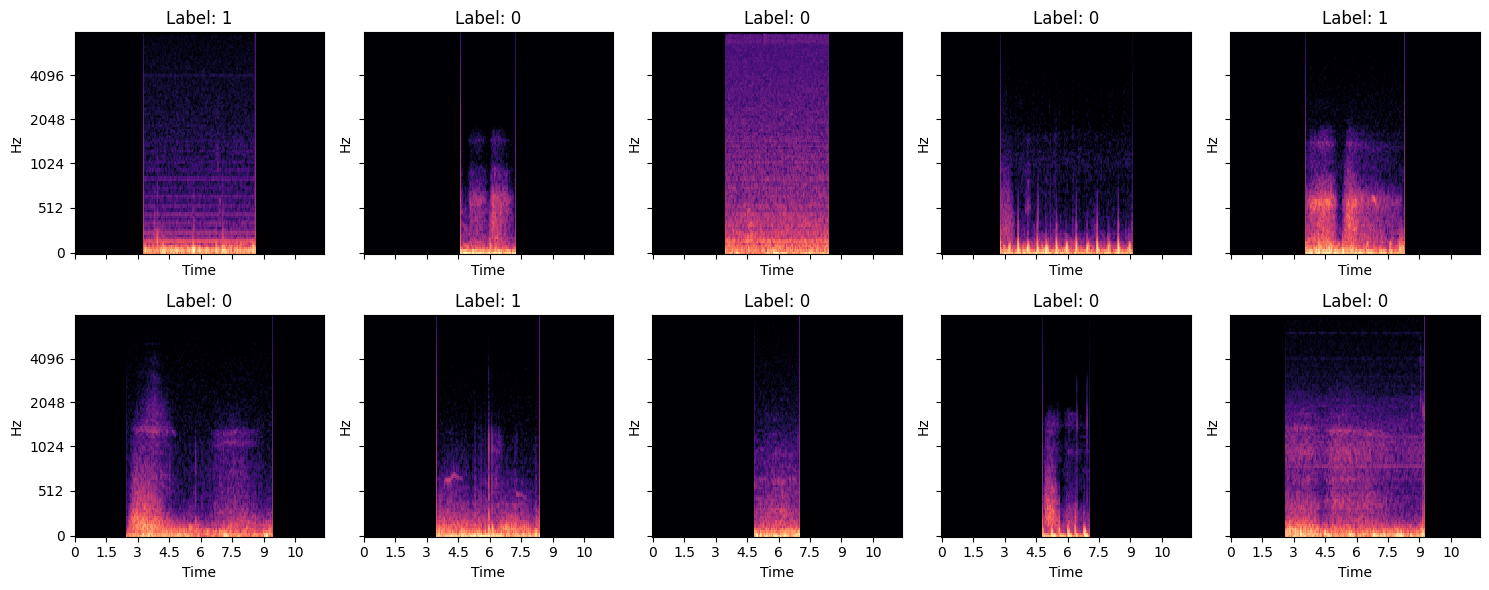

In [14]:
fig, axs = plt.subplots(2, 5, figsize=(15,6), sharey=True, sharex=True)
for i in range(10):
    ax = axs[i//5, i%5]
    img = librosa.display.specshow(X_train_melspecs[i].reshape(N_MELS, -1), sr=SAMPLING_RATE, x_axis='time', y_axis='mel', n_fft=N_FFT, ax=ax, cmap='magma')
    ax.set_title(f'Label: {y_train[i]}')
plt.tight_layout();

Guardamos las matrices

In [15]:
np.savez_compressed(
    f'./data_procesada/ciclos/{dataset}/train_melspectrogram.npz',
    X=X_train_melspecs,
    y=y_train
)

np.savez_compressed(
    f'./data_procesada/ciclos/{dataset}/test_melspectrogram.npz',
    X=X_test_melspecs,
    y=y_test
)

#### Imagenes

También generamos imágenes con las matrices para entrenar la CNN.

Para las CNN se necesita un conjunto de validacion, es mejor definirlo ahora asi es consistente.

In [17]:
X_train_melspecs, X_val_melspecs, y_train, y_val = train_test_split(
    X_train_melspecs, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

Las imágenes tienen de tamaño `N_MELS` x `MAX_LENGTH`, en este caso 128 x 372.  
El ``MAX_LENGTH`` cambia dependiendo de la calidad temporal que se crea necesaria.

In [18]:
save_mel_images(X_train_melspecs.reshape(-1, N_MELS, 372), y_train, 'imgs/train', dataset)
save_mel_images(X_val_melspecs.reshape(-1, N_MELS, 372), y_val, 'imgs/val', dataset)
save_mel_images(X_test_melspecs.reshape(-1, N_MELS, 372), y_test, 'imgs/test', dataset)

### Atributos de audio

Para este procesamiento sólo necesitamos un transformer, además del resampler:
+ `FeatureExtractor`: extrae todos los atributos considerados para la clasificación

In [19]:
pipeline_feature_extraction = Pipeline([
    # ya estan resampleados
    ('feature_extractor', FeatureExtractor())
])

In [20]:
X_train_features = pipeline_feature_extraction.transform(X_train)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [21]:
X_test_features = pipeline_feature_extraction.transform(X_test)

In [22]:
np.savez_compressed(
    f'./data_procesada/ciclos/{dataset}/train_features.npz',
    X=X_train_features,
    y=y_train
)

np.savez_compressed(
    f'./data_procesada/ciclos/{dataset}/test_features.npz',
    X=X_test_features,
    y=y_test
)